# Checking the Survival Probability

We check the spectral properties of the Perron-Frobenius operator $\hat{O}$ to wrap our head around the correct expression for the survival probabilty $S(n) = \vert| \hat{O}^n | \psi_0 \rangle \vert|^2$.

In [1]:
import numpy as np
import pandas as pd
from scipy.linalg import expm 
import matplotlib.pyplot as plt 

##########################################
# graph size and chirality
##########################################

num_sites = 21
target_site = num_sites // 2
#phi = 0
phi = np.pi/(2*num_sites)
#phi = np.pi/(num_sites)
tau = 1.30

##########################################
# Laplacian matrix for a 1D line (L = D - A)
##########################################

# on-site energies set to 0
diag = 0 * np.eye(num_sites)
# first-neighbor hopping
upper_diag = np.exp(1j * phi) * np.eye(num_sites, k=1)
lower_diag = np.exp(-1j * phi) * np.eye(num_sites, k=-1)

# sum
L = diag + upper_diag + lower_diag
# add periodic boundary conditions (it becomes a ring...)
L[0,-1] = np.exp(-1j * phi)
L[-1,0] = np.exp(1j * phi)

# check the form of the matrix
print(rf"Laplacian matrix L for N = {num_sites}, phi = {phi}")
df_L = pd.DataFrame(L)
pd.set_option("display.precision", 3)
display(df_L)

##########################################
# unitary evolution
##########################################
U = expm(-1j * L * tau)

print(rf"Unitary step with tau = {tau}")
df_U = pd.DataFrame(U)
pd.set_option("display.precision", 3)
display(df_U)

##########################################
# projector P = 1 - D
##########################################
P = np.eye(num_sites)
P[target_site,target_site] = 0

print(rf"Projector on the 'parallel' subspace, where |target> = |{target_site}>")
df_P = pd.DataFrame(P)
pd.set_option("display.precision", 3)
display(df_P)

##########################################
# Perron-Frobenius operator
##########################################
O = P @ U

print(rf"Perron-Frobenius (or survival) operator O = P U")
df_O = pd.DataFrame(O)
pd.set_option("display.precision", 3)
display(df_O)

Laplacian matrix L for N = 21, phi = 0.07479982508547127


,0,1,2,3,4,5,6,7,8,9,...,11,12,13,14,15,16,17,18,19,20
0,0.000+0.000j,0.997+0.075j,0.000+0.000j,0.000+0.000j,0.000+0.000j,0.000+0.000j,0.000+0.000j,0.000+0.000j,0.000+0.000j,0.000+0.000j,...,0.000+0.000j,0.000+0.000j,0.000+0.000j,0.000+0.000j,0.000+0.000j,0.000+0.000j,0.000+0.000j,0.000+0.000j,0.000+0.000j,0.997-0.075j
1,0.997-0.075j,0.000+0.000j,0.997+0.075j,0.000+0.000j,0.000+0.000j,0.000+0.000j,0.000+0.000j,0.000+0.000j,0.000+0.000j,0.000+0.000j,...,0.000+0.000j,0.000+0.000j,0.000+0.000j,0.000+0.000j,0.000+0.000j,0.000+0.000j,0.000+0.000j,0.000+0.000j,0.000+0.000j,0.000+0.000j
2,0.000+0.000j,0.997-0.075j,0.000+0.000j,0.997+0.075j,0.000+0.000j,0.000+0.000j,0.000+0.000j,0.000+0.000j,0.000+0.000j,0.000+0.000j,...,0.000+0.000j,0.000+0.000j,0.000+0.000j,0.000+0.000j,0.000+0.000j,0.000+0.000j,0.000+0.000j,0.000+0.000j,0.000+0.000j,0.000+0.000j
3,0.000+0.000j,0.000+0.000j,0.997-0.075j,0.000+0.000j,0.997+0.075j,0.000+0.000j,0.000+0.000j,0.000+0.000j,0.000+0.000j,0.000+0.000j,...,0.000+0.000j,0.000+0.000j,0.000+0.000j,0.000+0.000j,0.000+0.000j,0.000+0.000j,0.000+0.000j,0.000+0.000j,0.000+0.000j,0.000+0.000j
4,0.000+0.000j,0.000+0.000j,0.000+0.000j,0.997-0.075j,0.000+0.000j,0.997+0.075j,0.000+0.000j,0.000+0.000j,0.000+0.000j,0.000+0.000j,...,0.000+0.000j,0.000+0.000j,0.000+0.000j,0.000+0.000j,0.000+0.000j,0.000+0.000j,0.000+0.000j,0.000+0.000j,0.000+0.000j,0.000+0.000j
5,0.000+0.000j,0.000+0.000j,0.000+0.000j,0.000+0.000j,0.997-0.075j,0.000+0.000j,0.997+0.075j,0.000+0.000j,0.000+0.000j,0.000+0.000j,...,0.000+0.000j,0.000+0.000j,0.000+0.000j,0.000+0.000j,0.000+0.000j,0.000+0.000j,0.000+0.000j,0.000+0.000j,0.000+0.000j,0.000+0.000j
6,0.000+0.000j,0.000+0.000j,0.000+0.000j,0.000+0.000j,0.000+0.000j,0.997-0.075j,0.000+0.000j,0.997+0.075j,0.000+0.000j,0.000+0.000j,...,0.000+0.000j,0.000+0.000j,0.000+0.000j,0.000+0.000j,0.000+0.000j,0.000+0.000j,0.000+0.000j,0.000+0.000j,0.000+0.000j,0.000+0.000j
7,0.000+0.000j,0.000+0.000j,0.000+0.000j,0.000+0.000j,0.000+0.000j,0.000+0.000j,0.997-0.075j,0.000+0.000j,0.997+0.075j,0.000+0.000j,...,0.000+0.000j,0.000+0.000j,0.000+0.000j,0.000+0.000j,0.000+0.000j,0.000+0.000j,0.000+0.000j,0.000+0.000j,0.000+0.000j,0.000+0.000j
8,0.000+0.000j,0.000+0.000j,0.000+0.000j,0.000+0.000j,0.000+0.000j,0.000+0.000j,0.000+0.000j,0.997-0.075j,0.000+0.000j,0.997+0.075j,...,0.000+0.000j,0.000+0.000j,0.000+0.000j,0.000+0.000j,0.000+0.000j,0.000+0.000j,0.000+0.000j,0.000+0.000j,0.000+0.000j,0.000+0.000j
9,0.000+0.000j,0.000+0.000j,0.000+0.000j,0.000+0.000j,0.000+0.000j,0.000+0.000j,0.000+0.000j,0.000+0.000j,0.997-0.075j,0.000+0.000j,...,0.000+0.000j,0.000+0.000j,0.000+0.000j,0.000+0.000j,0.000+0.000j,0.000+0.000j,0.000+0.000j,0.000+0.000j,0.000+0.000j,0.000+0.000j


Unitary step with tau = 1.3


,0,1,2,3,4,5,6,7,8,9,...,11,12,13,14,15,16,17,18,19,20
0,-9.680e-02-3.954e-17j,3.518e-02-4.695e-01j,-4.538e-01-6.841e-02j,-5.236e-02+2.294e-01j,8.028e-02+2.476e-02j,8.479e-03-2.160e-02j,-4.727e-03-2.276e-03j,-5.027e-04+8.707e-04j,1.383e-04+9.428e-05j,1.539e-05-1.930e-05j,...,-2.672e-06+2.479e-06j,-1.534e-05-1.924e-05j,1.383e-04-9.429e-05j,5.027e-04+8.707e-04j,-4.727e-03+2.276e-03j,-8.479e-03-2.160e-02j,8.028e-02-2.476e-02j,5.236e-02+2.294e-01j,-4.538e-01+6.841e-02j,-3.518e-02-4.695e-01j
1,-3.518e-02-4.695e-01j,-9.680e-02+1.065e-17j,3.518e-02-4.695e-01j,-4.538e-01-6.841e-02j,-5.236e-02+2.294e-01j,8.028e-02+2.476e-02j,8.479e-03-2.160e-02j,-4.727e-03-2.276e-03j,-5.027e-04+8.707e-04j,1.383e-04+9.428e-05j,...,-2.100e-06-1.949e-06j,-2.672e-06+2.479e-06j,-1.534e-05-1.924e-05j,1.383e-04-9.429e-05j,5.027e-04+8.707e-04j,-4.727e-03+2.276e-03j,-8.479e-03-2.160e-02j,8.028e-02-2.476e-02j,5.236e-02+2.294e-01j,-4.538e-01+6.841e-02j
2,-4.538e-01+6.841e-02j,-3.518e-02-4.695e-01j,-9.680e-02-3.990e-17j,3.518e-02-4.695e-01j,-4.538e-01-6.841e-02j,-5.236e-02+2.294e-01j,8.028e-02+2.476e-02j,8.479e-03-2.160e-02j,-4.727e-03-2.276e-03j,-5.027e-04+8.707e-04j,...,1.539e-05-1.930e-05j,-2.100e-06-1.949e-06j,-2.672e-06+2.479e-06j,-1.534e-05-1.924e-05j,1.383e-04-9.429e-05j,5.027e-04+8.707e-04j,-4.727e-03+2.276e-03j,-8.479e-03-2.160e-02j,8.028e-02-2.476e-02j,5.236e-02+2.294e-01j
3,5.236e-02+2.294e-01j,-4.538e-01+6.841e-02j,-3.518e-02-4.695e-01j,-9.680e-02-4.798e-18j,3.518e-02-4.695e-01j,-4.538e-01-6.841e-02j,-5.236e-02+2.294e-01j,8.028e-02+2.476e-02j,8.479e-03-2.160e-02j,-4.727e-03-2.276e-03j,...,1.383e-04+9.428e-05j,1.539e-05-1.930e-05j,-2.100e-06-1.949e-06j,-2.672e-06+2.479e-06j,-1.534e-05-1.924e-05j,1.383e-04-9.429e-05j,5.027e-04+8.707e-04j,-4.727e-03+2.276e-03j,-8.479e-03-2.160e-02j,8.028e-02-2.476e-02j
4,8.028e-02-2.476e-02j,5.236e-02+2.294e-01j,-4.538e-01+6.841e-02j,-3.518e-02-4.695e-01j,-9.680e-02+1.908e-17j,3.518e-02-4.695e-01j,-4.538e-01-6.841e-02j,-5.236e-02+2.294e-01j,8.028e-02+2.476e-02j,8.479e-03-2.160e-02j,...,-5.027e-04+8.707e-04j,1.383e-04+9.428e-05j,1.539e-05-1.930e-05j,-2.100e-06-1.949e-06j,-2.672e-06+2.479e-06j,-1.534e-05-1.924e-05j,1.383e-04-9.429e-05j,5.027e-04+8.707e-04j,-4.727e-03+2.276e-03j,-8.479e-03-2.160e-02j
5,-8.479e-03-2.160e-02j,8.028e-02-2.476e-02j,5.236e-02+2.294e-01j,-4.538e-01+6.841e-02j,-3.518e-02-4.695e-01j,-9.680e-02+1.328e-17j,3.518e-02-4.695e-01j,-4.538e-01-6.841e-02j,-5.236e-02+2.294e-01j,8.028e-02+2.476e-02j,...,-4.727e-03-2.276e-03j,-5.027e-04+8.707e-04j,1.383e-04+9.428e-05j,1.539e-05-1.930e-05j,-2.100e-06-1.949e-06j,-2.672e-06+2.479e-06j,-1.534e-05-1.924e-05j,1.383e-04-9.429e-05j,5.027e-04+8.707e-04j,-4.727e-03+2.276e-03j
6,-4.727e-03+2.276e-03j,-8.479e-03-2.160e-02j,8.028e-02-2.476e-02j,5.236e-02+2.294e-01j,-4.538e-01+6.841e-02j,-3.518e-02-4.695e-01j,-9.680e-02-2.255e-17j,3.518e-02-4.695e-01j,-4.538e-01-6.841e-02j,-5.236e-02+2.294e-01j,...,8.479e-03-2.160e-02j,-4.727e-03-2.276e-03j,-5.027e-04+8.707e-04j,1.383e-04+9.428e-05j,1.539e-05-1.930e-05j,-2.100e-06-1.949e-06j,-2.672e-06+2.479e-06j,-1.534e-05-1.924e-05j,1.383e-04-9.429e-05j,5.027e-04+8.707e-04j
7,5.027e-04+8.707e-04j,-4.727e-03+2.276e-03j,-8.479e-03-2.160e-02j,8.028e-02-2.476e-02j,5.236e-02+2.294e-01j,-4.538e-01+6.841e-02j,-3.518e-02-4.695e-01j,-9.680e-02+1.361e-17j,3.518e-02-4.695e-01j,-4.538e-01-6.841e-02j,...,8.028e-02+2.476e-02j,8.479e-03-2.160e-02j,-4.727e-03-2.276e-03j,-5.027e-04+8.707e-04j,1.383e-04+9.428e-05j,1.539e-05-1.930e-05j,-2.100e-06-1.949e-06j,-2.672e-06+2.479e-06j,-1.534e-05-1.924e-05j,1.383e-04-9.429e-05j
8,1.383e-04-9.429e-05j,5.027e-04+8.707e-04j,-4.727e-03+2.276e-03j,-8.479e-03-2.160e-02j,8.028e-02-2.476e-02j,5.236e-02+2.294e-01j,-4.538e-01+6.841e-02j,-3.518e-02-4.695e-01j,-9.680e-02+1.735e-17j,3.518e-02-4.695e-01j,...,-5.236e-02+2.294e-01j,8.028e-02+2.476e-02j,8.479e-03-2.160e-02j,-4.727e-03-2.276e-03j,-5.027e-04+8.707e-04j,1.383e-04+9.428e-05j,1.539e-05-1.930e-05j,-2.100e-06-1.949e-06j,-2.672e-06+2.479e-06j,-1.534e-05-1.924e-05j
9,-1.534

Projector on the 'parallel' subspace, where |target> = |10>


,0,1,2,3,4,5,6,7,8,9,...,11,12,13,14,15,16,17,18,19,20
0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Perron-Frobenius (or survival) operator O = P U


,0,1,2,3,4,5,6,7,8,9,...,11,12,13,14,15,16,17,18,19,20
0,-9.680e-02-3.954e-17j,3.518e-02-4.695e-01j,-4.538e-01-6.841e-02j,-5.236e-02+2.294e-01j,8.028e-02+2.476e-02j,8.479e-03-2.160e-02j,-4.727e-03-2.276e-03j,-5.027e-04+8.707e-04j,1.383e-04+9.428e-05j,1.539e-05-1.930e-05j,...,-2.672e-06+2.479e-06j,-1.534e-05-1.924e-05j,1.383e-04-9.429e-05j,5.027e-04+8.707e-04j,-4.727e-03+2.276e-03j,-8.479e-03-2.160e-02j,8.028e-02-2.476e-02j,5.236e-02+2.294e-01j,-4.538e-01+6.841e-02j,-3.518e-02-4.695e-01j
1,-3.518e-02-4.695e-01j,-9.680e-02+1.065e-17j,3.518e-02-4.695e-01j,-4.538e-01-6.841e-02j,-5.236e-02+2.294e-01j,8.028e-02+2.476e-02j,8.479e-03-2.160e-02j,-4.727e-03-2.276e-03j,-5.027e-04+8.707e-04j,1.383e-04+9.428e-05j,...,-2.100e-06-1.949e-06j,-2.672e-06+2.479e-06j,-1.534e-05-1.924e-05j,1.383e-04-9.429e-05j,5.027e-04+8.707e-04j,-4.727e-03+2.276e-03j,-8.479e-03-2.160e-02j,8.028e-02-2.476e-02j,5.236e-02+2.294e-01j,-4.538e-01+6.841e-02j
2,-4.538e-01+6.841e-02j,-3.518e-02-4.695e-01j,-9.680e-02-3.990e-17j,3.518e-02-4.695e-01j,-4.538e-01-6.841e-02j,-5.236e-02+2.294e-01j,8.028e-02+2.476e-02j,8.479e-03-2.160e-02j,-4.727e-03-2.276e-03j,-5.027e-04+8.707e-04j,...,1.539e-05-1.930e-05j,-2.100e-06-1.949e-06j,-2.672e-06+2.479e-06j,-1.534e-05-1.924e-05j,1.383e-04-9.429e-05j,5.027e-04+8.707e-04j,-4.727e-03+2.276e-03j,-8.479e-03-2.160e-02j,8.028e-02-2.476e-02j,5.236e-02+2.294e-01j
3,5.236e-02+2.294e-01j,-4.538e-01+6.841e-02j,-3.518e-02-4.695e-01j,-9.680e-02-4.798e-18j,3.518e-02-4.695e-01j,-4.538e-01-6.841e-02j,-5.236e-02+2.294e-01j,8.028e-02+2.476e-02j,8.479e-03-2.160e-02j,-4.727e-03-2.276e-03j,...,1.383e-04+9.428e-05j,1.539e-05-1.930e-05j,-2.100e-06-1.949e-06j,-2.672e-06+2.479e-06j,-1.534e-05-1.924e-05j,1.383e-04-9.429e-05j,5.027e-04+8.707e-04j,-4.727e-03+2.276e-03j,-8.479e-03-2.160e-02j,8.028e-02-2.476e-02j
4,8.028e-02-2.476e-02j,5.236e-02+2.294e-01j,-4.538e-01+6.841e-02j,-3.518e-02-4.695e-01j,-9.680e-02+1.908e-17j,3.518e-02-4.695e-01j,-4.538e-01-6.841e-02j,-5.236e-02+2.294e-01j,8.028e-02+2.476e-02j,8.479e-03-2.160e-02j,...,-5.027e-04+8.707e-04j,1.383e-04+9.428e-05j,1.539e-05-1.930e-05j,-2.100e-06-1.949e-06j,-2.672e-06+2.479e-06j,-1.534e-05-1.924e-05j,1.383e-04-9.429e-05j,5.027e-04+8.707e-04j,-4.727e-03+2.276e-03j,-8.479e-03-2.160e-02j
5,-8.479e-03-2.160e-02j,8.028e-02-2.476e-02j,5.236e-02+2.294e-01j,-4.538e-01+6.841e-02j,-3.518e-02-4.695e-01j,-9.680e-02+1.328e-17j,3.518e-02-4.695e-01j,-4.538e-01-6.841e-02j,-5.236e-02+2.294e-01j,8.028e-02+2.476e-02j,...,-4.727e-03-2.276e-03j,-5.027e-04+8.707e-04j,1.383e-04+9.428e-05j,1.539e-05-1.930e-05j,-2.100e-06-1.949e-06j,-2.672e-06+2.479e-06j,-1.534e-05-1.924e-05j,1.383e-04-9.429e-05j,5.027e-04+8.707e-04j,-4.727e-03+2.276e-03j
6,-4.727e-03+2.276e-03j,-8.479e-03-2.160e-02j,8.028e-02-2.476e-02j,5.236e-02+2.294e-01j,-4.538e-01+6.841e-02j,-3.518e-02-4.695e-01j,-9.680e-02-2.255e-17j,3.518e-02-4.695e-01j,-4.538e-01-6.841e-02j,-5.236e-02+2.294e-01j,...,8.479e-03-2.160e-02j,-4.727e-03-2.276e-03j,-5.027e-04+8.707e-04j,1.383e-04+9.428e-05j,1.539e-05-1.930e-05j,-2.100e-06-1.949e-06j,-2.672e-06+2.479e-06j,-1.534e-05-1.924e-05j,1.383e-04-9.429e-05j,5.027e-04+8.707e-04j
7,5.027e-04+8.707e-04j,-4.727e-03+2.276e-03j,-8.479e-03-2.160e-02j,8.028e-02-2.476e-02j,5.236e-02+2.294e-01j,-4.538e-01+6.841e-02j,-3.518e-02-4.695e-01j,-9.680e-02+1.361e-17j,3.518e-02-4.695e-01j,-4.538e-01-6.841e-02j,...,8.028e-02+2.476e-02j,8.479e-03-2.160e-02j,-4.727e-03-2.276e-03j,-5.027e-04+8.707e-04j,1.383e-04+9.428e-05j,1.539e-05-1.930e-05j,-2.100e-06-1.949e-06j,-2.672e-06+2.479e-06j,-1.534e-05-1.924e-05j,1.383e-04-9.429e-05j
8,1.383e-04-9.429e-05j,5.027e-04+8.707e-04j,-4.727e-03+2.276e-03j,-8.479e-03-2.160e-02j,8.028e-02-2.476e-02j,5.236e-02+2.294e-01j,-4.538e-01+6.841e-02j,-3.518e-02-4.695e-01j,-9.680e-02+1.735e-17j,3.518e-02-4.695e-01j,...,-5.236e-02+2.294e-01j,8.028e-02+2.476e-02j,8.479e-03-2.160e-02j,-4.727e-03-2.276e-03j,-5.027e-04+8.707e-04j,1.383e-04+9.428e-05j,1.539e-05-1.930e-05j,-2.100e-06-1.949e-06j,-2.672e-06+2.479e-06j,-1.534e-05-1.924e-05j
9,-1.534

### Conflicting Formulas

Now we wish to check two formulas for the survival probability :

$$ S_1(n) = \sum_{j=0}^{N-1} |\mu_j|^{2n} \langle \psi_0 | \mu_j \rangle \langle \bar{\mu}_j | \psi_0 \rangle ,$$

$$ S_2(n) = \sum_{j,k=0}^{N-1} (\mu_j^* \mu_k)^n \langle \mu_j | \mu_k \rangle \langle \psi_0 | \bar{\mu}_j \rangle  \langle \bar{\mu}_k | \psi_0 \rangle .$$

We first need some functions.

In [2]:
from scipy.linalg import eig

##########################################
# 1) compute all eigenvalues
##########################################

def calculate_eigenvalues(matrix):
    return np.linalg.eigvals(matrix)

##########################################
# 2) look for degeneracy or modulus one
##########################################

def check_degeneracy(eigenvalues, tolerance=1e-4):
    n = len(eigenvalues)
    for i in range(n):
        for j in range(i+1,n):
            if np.isclose(eigenvalues[i],eigenvalues[j], atol=tolerance):
                return True
    return False

def check_modulus_one(eigenvalues, tolerance=1e-4):
    n = len(eigenvalues)
    for i in range(n):
        if np.isclose(np.abs(eigenvalues[i]), 1.0, atol=tolerance):
            return True
    return False

##########################################
# 3) plot complex eigenvalues
##########################################
def plot_eigenvalues(eigenvalues):
    # "zorder" defines the order in which things are drawn 
    plt.figure(figsize=(6,6))
    plt.scatter(eigenvalues.real, eigenvalues.imag, color='g', marker='o', zorder=3, label='eigenvalues')
    # axes 
    plt.axhline(0, color='black',linewidth=1, zorder=1)
    plt.axvline(0, color='black',linewidth=1, zorder=1)
    # unit circle (basically drawn with the help of polar coordinates)
    theta = np.linspace(0, 2*np.pi, 200)
    plt.plot(np.cos(theta), np.sin(theta), 'r--', alpha=0.5, zorder=2)
    # labels and proper plotting
    plt.xlabel('Re(z)')
    plt.ylabel('Im(z)')
    plt.grid(True, linestyle=':', alpha=0.7)
    plt.axis('equal') # makes sure the ratio is 1:1
    plt.legend()
    plt.show()

##########################################
# 4) highest-modulus eigenvalue as a funct. of phi and tau
##########################################

def plot_O_leading_eigenvalue(num_sites, target_site, resolution = 350, tau_min = 0.02, tau_max = 3.00):
    phi_min = 0
    phi_max = +np.pi/num_sites
    tau_vals = np.linspace(tau_min, tau_max, resolution)
    phi_vals = np.linspace(phi_min, phi_max, resolution)

    Tau_grid, Phi_grid = np.meshgrid(tau_vals, phi_vals)
    max_mod_matrix = np.zeros_like(Tau_grid)

    # static projector
    Proj = np.eye(num_sites)
    Proj[target_site, target_site] = 0
    
    for i in range(Tau_grid.shape[0]):
        for j in range(Tau_grid.shape[1]):

            # pick values from the grid to make L (and H, and U...)
            current_tau = Tau_grid[i, j]
            current_phi = Phi_grid[i, j]
            # first-neigh.
            upper_diag_temp = np.exp(1j * current_phi) * np.eye(num_sites, k=1)
            lower_diag_temp = np.exp(-1j * current_phi) * np.eye(num_sites, k=-1)
            # periodic b.c.
            L_temp = upper_diag_temp + lower_diag_temp
            L_temp[0, -1] = np.exp(-1j * current_phi)
            L_temp[-1, 0] = np.exp(1j * current_phi)

            # O as a function of phi and tau!
            U_temp = expm(-1j * L_temp * current_tau)
            O_temp = Proj @ U_temp

            # find the greatest eigenvalue
            evals = np.linalg.eigvals(O_temp)
            max_mod_matrix[i, j] = np.max(np.abs(evals))

    plt.figure(figsize=(8,6))
    contour = plt.contour(Tau_grid, Phi_grid, max_mod_matrix, levels=100, cmap='viridis')
    #heatmap = plt.pcolormesh(Tau_grid, Phi_grid, max_mod_matrix, cmap='viridis', shading='auto')
    plt.colorbar(contour, label=f'max |\u03BC| of O')
    #plt.colorbar(heatmap, label=rf'max |\mu| of O')
    plt.xlabel('\u03C4')
    plt.ylabel('\u03C6')
    plt.show()
    
##########################################
# 5) biorthogonal decomposition
##########################################

def biorthogonal_decomposition(matrix):
    evals, left_evecs, right_evecs = eig(matrix, left=True, right=True)
    # normalization
    # i is the index of the eigenvector
    # : runs over its components
    for i in range(len(evals)): 
        overlap = np.vdot(left_evecs[:,i], right_evecs[:,i])
        if np.abs(overlap) > 1e-15: # don't wanna be dividing by 0...
            left_evecs[:, i] = left_evecs[:, i] / np.conj(overlap)

    return evals, left_evecs, right_evecs

##########################################
# 6) S_1(n) and S_2(n)
##########################################

import warnings

def plot_survival_probabilities(O_matrix, num_steps = 50, psi_0 = None, tolerance=1e-8, ymin=0.001, ymax=0.6, logscale=False):

    N = O_matrix.shape[0]

    # if not otherwise specified, the initial state is localized at |0> 
    if psi_0 is None: 
        psi_0 = np.zeros(N, dtype=complex)
        psi_0[0] = 1.0

    mu, L_evecs, R_evecs = biorthogonal_decomposition(O_matrix)

    n_vals = np.arange(1, num_steps + 1) # given as an input to the function
    S1_vals = np.zeros(num_steps, dtype=float)
    S2_vals = np.zeros(num_steps, dtype=float)

    for idx, n in enumerate(n_vals):

        ############ S_1(n) ############  
         
        s1 = 0.0 + 0.0j

        for j in range(N):
            factor1 = np.abs(mu[j])**(2*n)
            factor2 = np.vdot(psi_0, R_evecs[:, j]) # <psi_0|mu_j>
            factor3 = np.vdot(L_evecs[:, j], psi_0) # <mu_bar_j|psi_0>
            s1 += factor1 * factor2 * factor3

        if np.abs(np.imag(s1)) > tolerance:
            warnings.warn(f"S_1(n={n}) has a non-negligible Im part = {np.imag(s1):.2e}")

        S1_vals[idx] = np.real(s1)

        ############ S_2(n) ############  

        s2 = 0.0 + 0.0j

        for j in range(N):
            for k in range(N):
                factor1 = (np.conj(mu[j])*mu[k])**n
                factor2 =  np.vdot(R_evecs[:, j], R_evecs[:, k]) # <mu_j|mu_k>                 
                factor3 =  np.vdot(psi_0, L_evecs[:, j]) # <psi_0|mu_bar_j> 
                factor4 =  np.vdot(L_evecs[:, k], psi_0) # <mu_bar_k|psi_0>
                s2 += factor1 * factor2 * factor3 * factor4

        if np.abs(np.imag(s2)) > tolerance:
            warnings.warn(f"S_2(n={n}) has a non-negligible Im part = {np.imag(s2):.2e}")
        
        S2_vals[idx] = np.real(s2)

    # plot for colorblind
    plt.figure(figsize=(9,6))
    plt.plot(n_vals, S1_vals, label='$S_1(n)$', color='#0072B2', linestyle='-', marker='o', alpha=0.8)
    plt.plot(n_vals, S2_vals, label='$S_2(n)$', color='#D55E00', linestyle='--', marker='x', alpha=0.8)
    plt.xlabel('step $n$')
    plt.ylabel('survival probability')
    plt.ylim(ymin,ymax)
    if logscale:
        plt.yscale('log')
    plt.legend()
    plt.grid(True, linestyle=':', alpha=0.7)
    plt.show()
            



### Numerical Comparison

We now wanna compare $S_1$ and $S_2$ as a function of $n$, to see how different they are and if they converge to the same value as $n \to \infty$.

Parameters:
N = 21, phi = 50.0 % of pi/N, tau = 1.3
List of eigenvalues:
[ 0.8062664 -3.48233517e-01j  0.87590995+2.35922393e-16j
  0.8062664 +3.48233517e-01j  0.61330134+6.38282837e-01j
  0.33883841+8.29845580e-01j  0.03557248+9.10547760e-01j
 -0.24932684+8.94956629e-01j -0.48500002+8.15169921e-01j
 -0.65918815+7.08737443e-01j -0.8368923 +5.39974337e-01j
 -0.77368689+6.08985798e-01j  0.61330134-6.38282837e-01j
  0.33883841-8.29845580e-01j  0.03557248-9.10547760e-01j
 -0.24932684-8.94956629e-01j -0.48500002-8.15169921e-01j
 -0.65918815-7.08737443e-01j -0.8368923 -5.39974337e-01j
 -0.77368689-6.08985798e-01j -0.39177791-1.00361860e-16j
  0.        +0.00000000e+00j]
Is the spectrum of O degenerate? False
Any modulus one eigenvalue? False


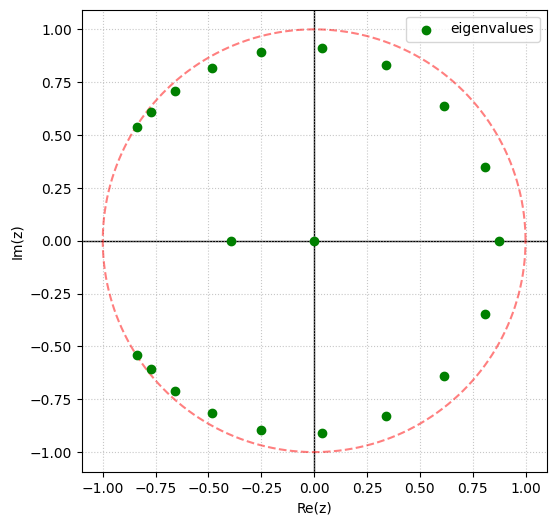

In [3]:
# 1) get the eigenvalues of the P.-F. operator

eigenvalues_O = calculate_eigenvalues(O)

print(f"Parameters:")
print(rf"N = {num_sites}, phi = {100.0*phi/(np.pi/num_sites)} % of pi/N, tau = {tau}")

print(f"List of eigenvalues:")
print(eigenvalues_O)

# 2) check degeneracy and modulus 1

has_deg = check_degeneracy(eigenvalues_O)
print(f"Is the spectrum of O degenerate? {has_deg}")

has_mod_one = check_modulus_one(eigenvalues_O)
print(f"Any modulus one eigenvalue? {has_mod_one}")

# 3) plot on the complex plane

plot_eigenvalues(eigenvalues_O)

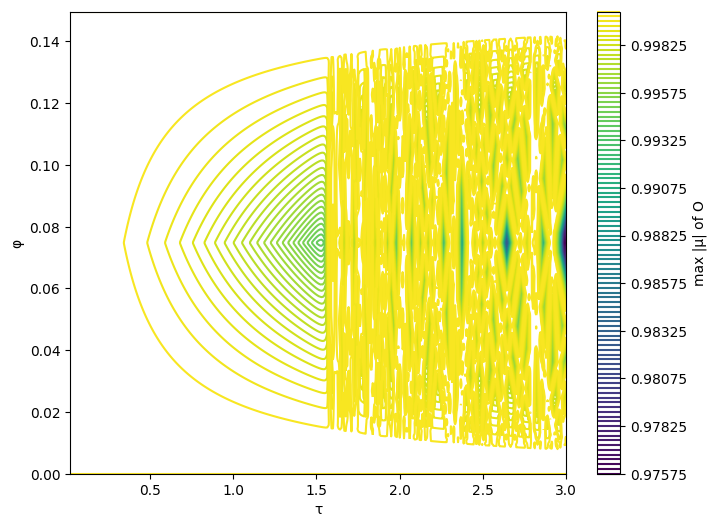

In [4]:
# 4) plot the eigenvalues of O as a function of phi and tau!
N = 21
plot_O_leading_eigenvalue(N, N//2)

In [5]:
# 5) carry out the biorthogonal decomposition
evals_B_decomp, L_Evecs, R_Evecs = biorthogonal_decomposition(O)
# check for biorthogonality
biorthogonality_check = L_Evecs.conj().T @ R_Evecs
print("L^dagger @ R (should be ~ Identity):\n")
#df_BC = pd.DataFrame(biorthogonality_check)
df_BC = pd.DataFrame(np.round(biorthogonality_check, 6))
pd.set_option("display.precision", 3)
display(df_BC)

L^dagger @ R (should be ~ Identity):



,0,1,2,3,4,5,6,7,8,9,...,11,12,13,14,15,16,17,18,19,20
0,1.0+0.0j,-0.0-0.0j,-0.0+0.0j,-0.0+0.0j,-0.0+0.0j,0.0-0.0j,0.0+0.0j,-0.0-0.0j,-0.0-0.0j,-0.0-0.0j,...,-0.0-0.0j,-0.0+0.0j,0.0-0.0j,-0.0-0.0j,-0.0-0.0j,-0.0-0.0j,-0.0-0.0j,0.0-0.0j,0.0+0.0j,0.0+0.0j
1,-0.0+0.0j,1.0+0.0j,-0.0-0.0j,0.0-0.0j,-0.0-0.0j,-0.0+0.0j,-0.0+0.0j,-0.0-0.0j,0.0+0.0j,0.0+0.0j,...,-0.0-0.0j,-0.0+0.0j,0.0-0.0j,0.0-0.0j,0.0+0.0j,0.0-0.0j,-0.0-0.0j,0.0-0.0j,0.0-0.0j,0.0-0.0j
2,-0.0-0.0j,-0.0+0.0j,1.0-0.0j,0.0-0.0j,0.0-0.0j,-0.0-0.0j,-0.0+0.0j,0.0-0.0j,0.0+0.0j,-0.0+0.0j,...,0.0-0.0j,-0.0-0.0j,0.0-0.0j,0.0-0.0j,-0.0-0.0j,-0.0+0.0j,0.0+0.0j,0.0-0.0j,0.0-0.0j,-0.0-0.0j
3,0.0-0.0j,0.0+0.0j,0.0+0.0j,1.0+0.0j,0.0-0.0j,-0.0-0.0j,0.0-0.0j,0.0-0.0j,-0.0-0.0j,-0.0+0.0j,...,-0.0+0.0j,0.0+0.0j,-0.0+0.0j,0.0+0.0j,0.0-0.0j,-0.0+0.0j,0.0-0.0j,-0.0+0.0j,-0.0-0.0j,-0.0-0.0j
4,-0.0+0.0j,-0.0+0.0j,-0.0-0.0j,-0.0+0.0j,1.0-0.0j,0.0+0.0j,0.0+0.0j,-0.0-0.0j,0.0-0.0j,0.0-0.0j,...,-0.0-0.0j,-0.0+0.0j,-0.0-0.0j,-0.0-0.0j,-0.0+0.0j,0.0-0.0j,-0.0+0.0j,-0.0-0.0j,0.0-0.0j,0.0-0.0j
5,-0.0+0.0j,0.0+0.0j,0.0+0.0j,0.0-0.0j,0.0-0.0j,1.0+0.0j,-0.0-0.0j,0.0+0.0j,0.0-0.0j,-0.0-0.0j,...,0.0+0.0j,0.0+0.0j,-0.0+0.0j,-0.0+0.0j,0.0+0.0j,-0.0+0.0j,0.0-0.0j,-0.0+0.0j,0.0-0.0j,0.0-0.0j
6,0.0+0.0j,-0.0+0.0j,-0.0+0.0j,0.0+0.0j,0.0-0.0j,-0.0+0.0j,1.0+0.0j,-0.0+0.0j,0.0+0.0j,0.0-0.0j,...,-0.0+0.0j,0.0+0.0j,-0.0-0.0j,-0.0-0.0j,-0.0+0.0j,0.0-0.0j,0.0+0.0j,-0.0-0.0j,0.0-0.0j,0.0-0.0j
7,-0.0-0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j,-0.0-0.0j,-0.0-0.0j,1.0+0.0j,-0.0+0.0j,0.0-0.0j,...,-0.0-0.0j,-0.0-0.0j,0.0-0.0j,0.0-0.0j,0.0-0.0j,-0.0+0.0j,0.0-0.0j,0.0-0.0j,0.0+0.0j,0.0+0.0j
8,-0.0+0.0j,0.0-0.0j,0.0-0.0j,-0.0-0.0j,-0.0-0.0j,-0.0+0.0j,-0.0+0.0j,-0.0-0.0j,1.0-0.0j,0.0-0.0j,...,-0.0+0.0j,-0.0+0.0j,-0.0-0.0j,-0.0+0.0j,0.0-0.0j,-0.0-0.0j,0.0+0.0j,0.0-0.0j,0.0-0.0j,0.0-0.0j
9,0.0+0.0j,0.0+0.0j,0.0-0.0j,-0.0-0.0j,-0.0-0.0j,-0.0+0.0j,-0.0+0.0j,0.0+0.0j,0.0-0.0j,1.0+0.0j,...,0.0-0.0j,0.0-0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j,0.0-0.0j,-0.0+0.0j,0.0+0.0j,-0.0+0.0j,-0.0+0.0j


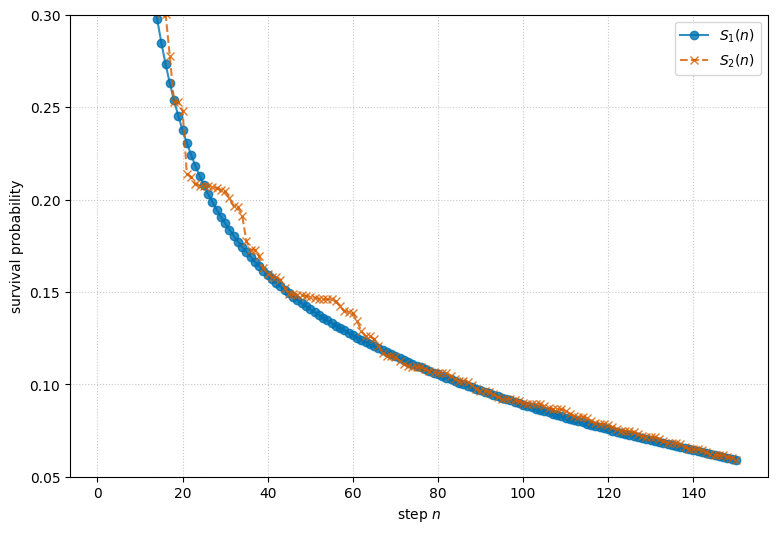

In [7]:
# 6) compare S_1 and S_2
plot_survival_probabilities(O, num_steps = 150, ymin=0.05, ymax=0.30)